<div style="font-size:40px; letter-spacing:-1px; font-family:Arial, sans-serif;">
  A M A L I T <span style="color:#f26a21; letter-spacing:0;">≡</span> C H
</div>

**Joseph Forson**  
<span style="font-size:16px;">Data Engineer Intern</span> <br>


# The Last Mile Logistics Auditor Project

### Delivery Performance Audit for *Veridi Logistics*

**Business question (from the CEO):** "Are we failing specific regions, or is this a nationwide problem?"

She suspects we are **over-promising and under-delivering** in such a way that the *estimated* delivery dates shown to customers are inaccurate, which is driving some spikes in negative reviews.

This notebook audits the [Olist Brazilian E-Commerce dataset](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) to find the root cause and connect **logistics performance** to **customer sentiment** using data engineering techniques.



**The Walkthrough...**
1. **Prepare the given Data:** join fragments into one clean master table.
2. **Make Calculations:** measure estimate-vs-actual and classify On Time / Late / Super Late.
3. **Geographic Heatmap:** % late per state – is it regional?
4. **Sentiment Findings:** do late deliveries actually cause bad reviews?
5. **Translation:** Portuguese product categories → English.
6. **Some insightful routes**
7. **Executive findings & recommendations.**


<div style="margin-top: 3px;"></div>

## 0. Setup &  data loading

We assume the CSVs downloaded sit in the **same folder as
this notebook**.

> The Download them from the
> Kaggle link above and extract them into the same folder as this notebook.


Required packages

```bash
pip install numpy pandas matplotlib seaborn
```

In the notebook cells, you can also install them as

```python
!pip install numpy pandas matplotlib seaborn
```

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

# Data
KAGGLE_URL = "https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce"
REQUIRED_FILES = [
    "olist_orders_dataset.csv",
    "olist_order_reviews_dataset.csv",
    "olist_customers_dataset.csv",
    "olist_products_dataset.csv",
    "olist_order_items_dataset.csv",
    "olist_geolocation_dataset.csv",            
    "olist_order_payments_dataset.csv",         
    "product_category_name_translation.csv",
]

# CHecking files are intact before we start
missing = [f for f in REQUIRED_FILES if not os.path.isfile(f)]
if missing:
    raise FileNotFoundError(
        "Missing dataset file(s):\n  - " + "\n  - ".join(missing)
        + f"\n\nDownload the Olist dataset from {KAGGLE_URL} and extract the CSVs "
          "into the same folder as this notebook, then re-run."
    )

print(f"All {len(REQUIRED_FILES)} required files found in:", os.path.abspath("."))

All 8 required files found in: /home/redsteam/Desktop/bear/ML/amal_challenge


## Load Data

In [2]:
orders    = pd.read_csv("olist_orders_dataset.csv")
reviews   = pd.read_csv("olist_order_reviews_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
products  = pd.read_csv("olist_products_dataset.csv")
items     = pd.read_csv("olist_order_items_dataset.csv")      
translation = pd.read_csv("product_category_name_translation.csv")

for name, df in [("orders", orders), ("reviews", reviews), ("customers", customers),
                 ("products", products), ("order_items", items)]:
    print(f"{name:12s} rows={len(df):>7,}  cols={df.shape[1]}")

orders       rows= 99,441  cols=8
reviews      rows= 99,224  cols=7
customers    rows= 99,441  cols=5
products     rows= 32,951  cols=9
order_items  rows=112,650  cols=7


Looking into the datasets to be familiar with the column names and structure. As we get to know the data types and what ought to be converted, example dates being normal strings. This guides us in our  data exploration.


In [3]:
# Data read
for name, df in [("orders", orders), ("reviews", reviews), ("customers", customers)]:
    print(f"===== {name}  —  {df.shape[0]:,} rows x {df.shape[1]} cols =====")
    display(df.head(3))

# data types
print("Column dtypes:")
print(orders.dtypes)
#print(reviews.dtypes)
#print(customers.dtypes)

===== orders  —  99,441 rows x 8 cols =====


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


===== reviews  —  99,224 rows x 7 cols =====


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24


===== customers  —  99,441 rows x 5 cols =====


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


Column dtypes:
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object


### 0.2 Quick data-Integrity profile

We now know the shape of each table. We check these 3 core tables for issues. Due to the problem we are solving which involves reviews, order and customers, two problems arise:

- **Duplicate reviews** — some orders received more than one review. A naive join would
  *inflate* the order table and corrupt every percentage we compute.
- **Undelivered orders** — some orders have no `order_delivered_customer_date` (cancelled,
  unavailable, or still in transit). They have no "actual" delivery date, so they cannot be
  scored for lateness and must be excluded from the delay analysis.


In [4]:
# Reviews, is the order_id unique?
dup_orders = (reviews["order_id"].value_counts() > 1).sum()
print(f"Reviews: {len(reviews):,} rows, {reviews['order_id'].nunique():,} unique orders "
      f"-> {dup_orders:,} orders have MULTIPLE reviews (must de-duplicate before joining).")

# Orders status breakdown + missing delivery dates
print("\norder_status breakdown:")
print(orders["order_status"].value_counts())
print(f"\nMissing actual delivery date: {orders['order_delivered_customer_date'].isna().sum():,} orders")

Reviews: 99,224 rows, 98,673 unique orders -> 547 orders have MULTIPLE reviews (must de-duplicate before joining).

order_status breakdown:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Missing actual delivery date: 2,965 orders


## Story 1 — The Schema Builder

> *As a Data Engineer, I want to join Orders, Reviews and Customers into a single master dataset,
> so that I can analyse a customer's location and their review score in the same row.*

**Plan**
1. **De-duplicate reviews** so the join is strictly 1-to-1. When an order has several reviews we
   keep the **most recent** one (`review_creation_date`) 
   sentiment about the delivery.
2. Join **reviews → orders** on `order_id` (left join: keep every order even if unreviewed).
3. Join **customers → orders** on `customer_id`.
4. **Guard against row inflation.**


In [5]:
# 1. De-duplicate reviews i.e keep the most recent review per order
reviews["review_creation_date"] = pd.to_datetime(reviews["review_creation_date"])
reviews_dedup = (reviews
                 .sort_values("review_creation_date")
                 .drop_duplicates(subset="order_id", keep="last"))
print(f"Reviews de-duplicated: {len(reviews):,} -> {len(reviews_dedup):,} rows "
      f"(now one review per order: {reviews_dedup['order_id'].is_unique}).")

Reviews de-duplicated: 99,224 -> 98,673 rows (now one review per order: True).


In [6]:
# Master table
n_orders_before = len(orders)

master = (orders
          .merge(reviews_dedup[["order_id", "review_id", "review_score",
                                "review_creation_date"]],
                 on="order_id", how="left")
          .merge(customers[["customer_id", "customer_unique_id",
                            "customer_city", "customer_state"]],
                 on="customer_id", how="left"))

# 4. Row-inflation guard to  prevent 1-to-many joins
assert len(master) == n_orders_before, (
    f"Row inflation! orders={n_orders_before:,} but master={len(master):,}")
assert master["order_id"].is_unique, "order_id is not unique in master table!"
print(f"Master table built: {len(master):,} rows (== original orders, no inflation). PASS")
print(f"Orders with a review attached: {master['review_score'].notna().mean():.1%}")
master.head(3)

Master table built: 99,441 rows (== original orders, no inflation). PASS
Orders with a review attached: 99.2%


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_creation_date,customer_unique_id,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,a54f0611adc9ed256b57ede6b6eb5114,4.0,2017-10-11,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,8d5266042046a06655c8db133d120ba5,4.0,2018-08-08,af07308b275d755c9edb36a90c618231,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,e73b67b67587f7644d5bd1a52deb1b01,5.0,2018-08-18,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO


## Understanding the Data (before we engineer anything)

Before computing delays we profile the **master table** so we get a fair idea of the joined table. We look  at the structure & completeness, the
data's time span and the distribution.


In [7]:
# Structure, types and missingness of Master table
print("Master shape:", master.shape)
profile = pd.DataFrame({
    "dtype": master.dtypes.astype(str),
    "n_missing": master.isna().sum(),
    "pct_missing": (master.isna().mean() * 100).round(1),
})
print(profile.to_string())

Master shape: (99441, 14)


                                        dtype  n_missing  pct_missing
order_id                               object          0          0.0
customer_id                            object          0          0.0
order_status                           object          0          0.0
order_purchase_timestamp               object          0          0.0
order_approved_at                      object        160          0.2
order_delivered_carrier_date           object       1783          1.8
order_delivered_customer_date          object       2965          3.0
order_estimated_delivery_date          object          0          0.0
review_id                              object        768          0.8
review_score                          float64        768          0.8
review_creation_date           datetime64[ns]        768          0.8
customer_unique_id                     object          0          0.0
customer_city                          object          0          0.0
customer_state      

In [8]:
# Time span of the data
purchase = pd.to_datetime(master["order_purchase_timestamp"], errors="coerce")
print(f"Orders span: {purchase.min():%Y-%m-%d}  ->  {purchase.max():%Y-%m-%d}  "
      f"({(purchase.max() - purchase.min()).days} days)")

# Review-score distribution
print("\nReview-score distribution (NaN = order has no review):")
print(master["review_score"].value_counts(dropna=False).sort_index())

# Geographic concentration -
state_counts = master["customer_state"].value_counts()
print(f"\nStates represented: {state_counts.size}")
print("Top 5 states by order volume:", dict(state_counts.head(5)))
print(f"Top 3 states account for {state_counts.head(3).sum() / state_counts.sum():.0%} "
      "of all orders.")

Orders span: 2016-09-04  ->  2018-10-17  (772 days)

Review-score distribution (NaN = order has no review):
review_score
1.0    11365
2.0     3130
3.0     8134
4.0    19043
5.0    57001
NaN      768
Name: count, dtype: int64

States represented: 27
Top 5 states by order volume: {'SP': 41746, 'RJ': 12852, 'MG': 11635, 'RS': 5466, 'PR': 5045}
Top 3 states account for 67% of all orders.


In this work we find interest only on delivered items since we are doing lateness analysis.

Actual-delivery-date availability by order_status:
order_delivered_customer_date  no_delivery_date  has_delivery_date
order_status                                                      
approved                                      2                  0
canceled                                    619                  6
created                                       5                  0
delivered                                     8              96470
invoiced                                    314                  0
processing                                  301                  0
shipped                                    1107                  0
unavailable                                 609                  0


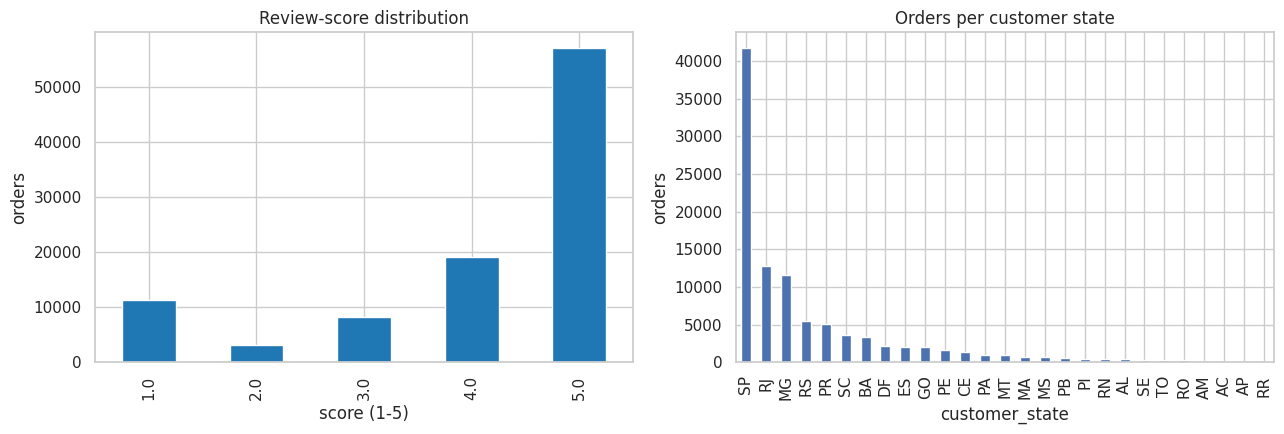

In [9]:
# Undelivered orders MUST be excluded
# only  when order_status == 'delivered'.
has_date = master["order_delivered_customer_date"].notna()
print("Actual-delivery-date availability by order_status:")
print(pd.crosstab(master["order_status"], has_date)
        .rename(columns={False: "no_delivery_date", True: "has_delivery_date"}))

# Visualise the review, and orders per customer state per order volume 
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
master["review_score"].value_counts().sort_index().plot.bar(
    ax=ax[0], color="#1f77b4")
ax[0].set_title("Review-score distribution"); ax[0].set_xlabel("score (1-5)")
ax[0].set_ylabel("orders")
state_counts.plot.bar(ax=ax[1], color="#4c72b0")
ax[1].set_title("Orders per customer state"); ax[1].set_ylabel("orders")
plt.tight_layout(); plt.show()

**What we've seen before we move on**

- **Time frame:** the orders span roughly **Sep 2016 → Oct 2018**.
- **Sentiment is J-shaped:** the ratings cluster at **5** and **1** with few in the middle.
  So the rating score moves sharply with experience.
- **Concentration in geography:** orders are dominated by the south-east (**SP, RJ, MG**). Small
  northern states have far fewer orders.
- **Delivery dates exist almost only for `delivered` orders**  that means the ~3k undelivered
  orders have *no* actual date and must be **excluded** from the  calculation we do.


## Story 2 — The "Real" Delay Calculator

> *As a Logistics Manager, I want the difference between the Estimated and Actual delivery date,
> so that I can see how often we are "lying" to customers.*


$$\text{Days\_Difference} = \text{order\_estimated\_delivery\_date} - \text{order\_delivered\_customer\_date}$$

Intuitively,

| Days_Difference | Meaning |
|---|---|
| **> 0** | delivered **early** (good) |
| **= 0** | delivered on the promised day |
| **< 0** | delivered **late** (we broke the promise) |

**Classification** (`> 5 days late` = *Super Late*):
- `On Time`  → `Days_Difference >= 0`
- `Late`     → `-5 <= Days_Difference < 0`
- `Super Late` → `Days_Difference < -5`

**Undelivered orders** (no actual delivery date) are excluded from the lateness analysis and
tracked separately so we never mistake a missing delivery for an on-time one.


In [10]:
date_cols = ["order_purchase_timestamp", "order_delivered_customer_date",
             "order_estimated_delivery_date"]
for c in date_cols:
    master[c] = pd.to_datetime(master[c], errors="coerce")

# Flag delivered vs not
master["is_delivered"] = (master["order_status"] == "delivered") & \
                         master["order_delivered_customer_date"].notna()
print("Delivered & datable orders:", f"{master['is_delivered'].sum():,}")
print("Excluded (undelivered / cancelled / in-transit):",
      f"{(~master['is_delivered']).sum():,}")

# Work on the delivered subset for our delay analysis
delivered = master[master["is_delivered"]].copy()

# Days_Difference (estimated - actual)
delivered["Days_Difference"] = (
    delivered["order_estimated_delivery_date"]
    - delivered["order_delivered_customer_date"]
).dt.days

def classify(d):
    if d >= 0:      return "On Time"
    if d >= -5:     return "Late"
    return "Super Late"

delivered["delivery_status"] = delivered["Days_Difference"].apply(classify)

status_order = ["On Time", "Late", "Super Late"]
summary = (delivered["delivery_status"].value_counts()
           .reindex(status_order))
summary_pct = (summary / summary.sum() * 100).round(1)
print("\nDelivery performance (delivered orders):")
for s in status_order:
    print(f"  {s:11s}: {summary[s]:>7,}  ({summary_pct[s]:>4}%)")

Delivered & datable orders: 96,470
Excluded (undelivered / cancelled / in-transit): 2,971

Delivery performance (delivered orders):
  On Time    :  88,644  (91.9%)
  Late       :   3,615  ( 3.7%)
  Super Late :   4,211  ( 4.4%)


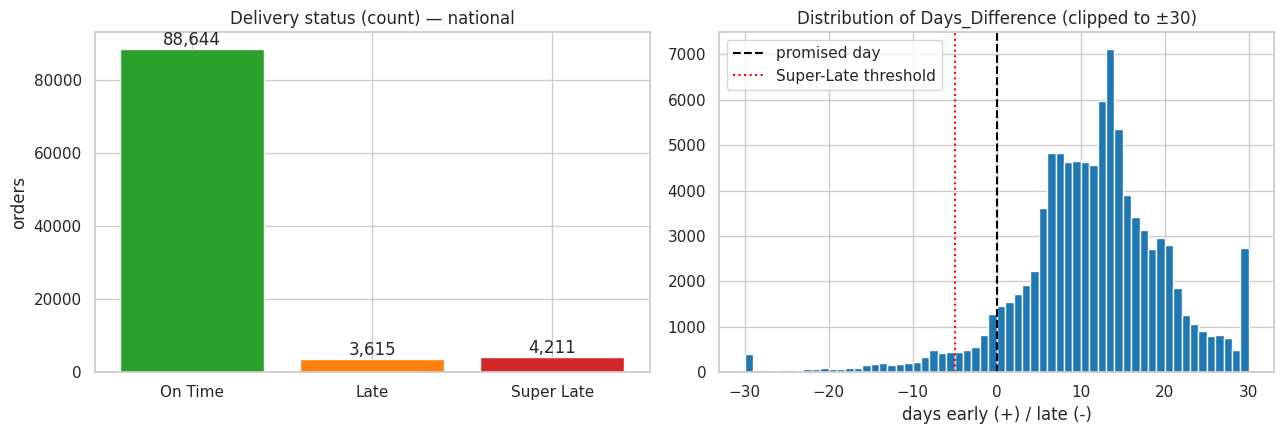

NATIONAL late rate (Late + Super Late): 8.1%


In [11]:
# Visualise the national baseline
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
colors = {"On Time": "#2ca02c", "Late": "#ff7f0e", "Super Late": "#d62728"}
ax[0].bar(status_order, summary.values, color=[colors[s] for s in status_order])
ax[0].set_title("Delivery status (count) — national")
ax[0].set_ylabel("orders")
for i, v in enumerate(summary.values):
    ax[0].text(i, v, f"{v:,}", ha="center", va="bottom")

ax[1].hist(delivered["Days_Difference"].clip(-30, 30), bins=60, color="#1f77b4")
ax[1].axvline(0, color="black", ls="--", label="promised day")
ax[1].axvline(-5, color="red", ls=":", label="Super-Late threshold")
ax[1].set_title("Distribution of Days_Difference (clipped to ±30)")
ax[1].set_xlabel("days early (+) / late (-)")
ax[1].legend()
plt.tight_layout(); plt.show()

late_rate = (delivered["delivery_status"] != "On Time").mean()
print(f"NATIONAL late rate (Late + Super Late): {late_rate:.1%}")

After focussing on only items with delivered status, 
- **On Time — 91.9%** (88,644): arrived on or before the promised date.
- **Late — 3.7%** (3,615): up to 5 days past the estimate.
- **Super Late — 4.4%** (4,211): more than 5 days past the estimate.

So the **national late rate is ~8.1%** (Late + Super Late). 

1. On the surface Veridi looks reliable because when we zoom out most parcels actually *beat* the estimate.
2. But that doesn't mean we should stop there, let's go individually.


## Story 3 — The Geographic Heatmap

> *As a Regional Director, I want to see which States have the highest % of late deliveries,
> so that I can focus repair efforts on the worst regions.*

We compute the **% late per `customer_state`** and compare each state to the national baseline.
A choropleth map answers the CEO's question on **is this nationwide, or regional?**


In [12]:
state_perf = (delivered
    .assign(is_late=delivered["delivery_status"] != "On Time")
    .groupby("customer_state")
    .agg(orders=("order_id", "size"),
         pct_late=("is_late", "mean"),
         avg_days_diff=("Days_Difference", "mean"))
    .reset_index())
state_perf["pct_late"] = (state_perf["pct_late"] * 100).round(1)
state_perf["avg_days_diff"] = state_perf["avg_days_diff"].round(1)
state_perf = state_perf.sort_values("pct_late", ascending=False)

national = late_rate * 100
print(f"National late rate: {national:.1f}%\n")
print("Worst 5 states:"); print(state_perf.head(5).to_string(index=False))
print("\nBest 5 states:");  print(state_perf.tail(5).to_string(index=False))

National late rate: 8.1%

Worst 5 states:
customer_state  orders  pct_late  avg_days_diff
            AL     397      23.9            7.7
            MA     717      19.7            8.6
            PI     476      16.0           10.3
            CE    1279      15.3            9.8
            SE     335      15.2            9.0

Best 5 states:
customer_state  orders  pct_late  avg_days_diff
            PR    4923       5.0           12.3
            AP      67       4.5           18.7
            AM     145       4.1           18.6
            AC      80       3.8           19.7
            RO     243       2.9           19.1


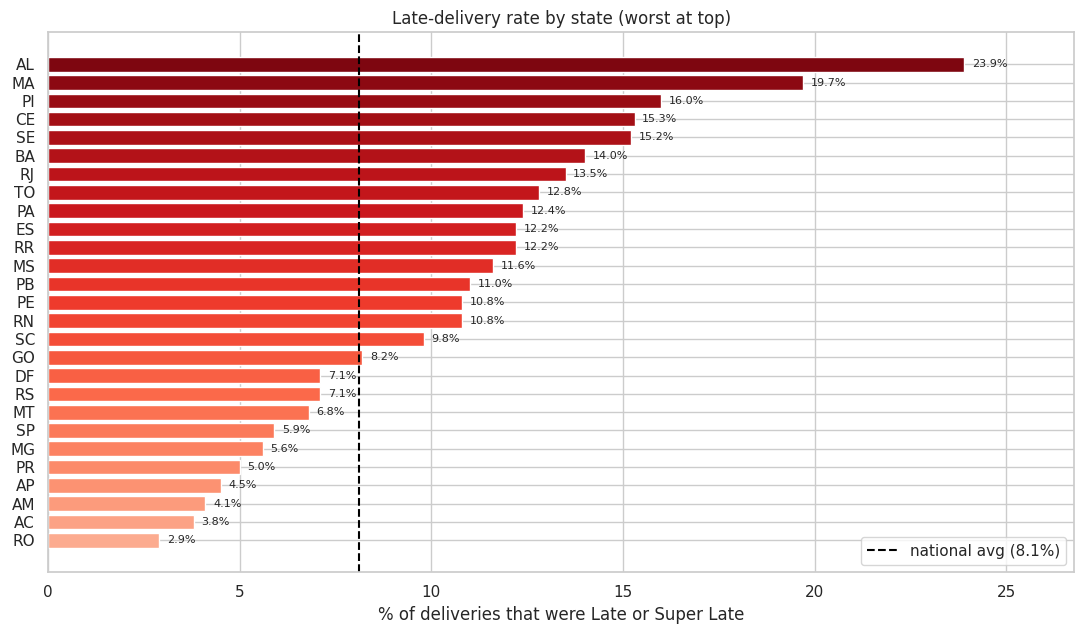

In [13]:
# Bar chart 
ranked = state_perf.sort_values("pct_late")           
fig, ax = plt.subplots(figsize=(11, 6.5))
ax.barh(ranked["customer_state"], ranked["pct_late"],
        color=plt.cm.Reds(np.linspace(0.3, 0.95, len(ranked))))
for y, v in enumerate(ranked["pct_late"]):
    ax.text(v + 0.2, y, f"{v:.1f}%", va="center", fontsize=8)
ax.axvline(national, color="black", ls="--", label=f"national avg ({national:.1f}%)")
ax.set_xlim(0, ranked["pct_late"].max() * 1.12)
ax.set_xlabel("% of deliveries that were Late or Super Late")
ax.set_title("Late-delivery rate by state (worst at top)")
ax.legend(); plt.tight_layout(); plt.show()

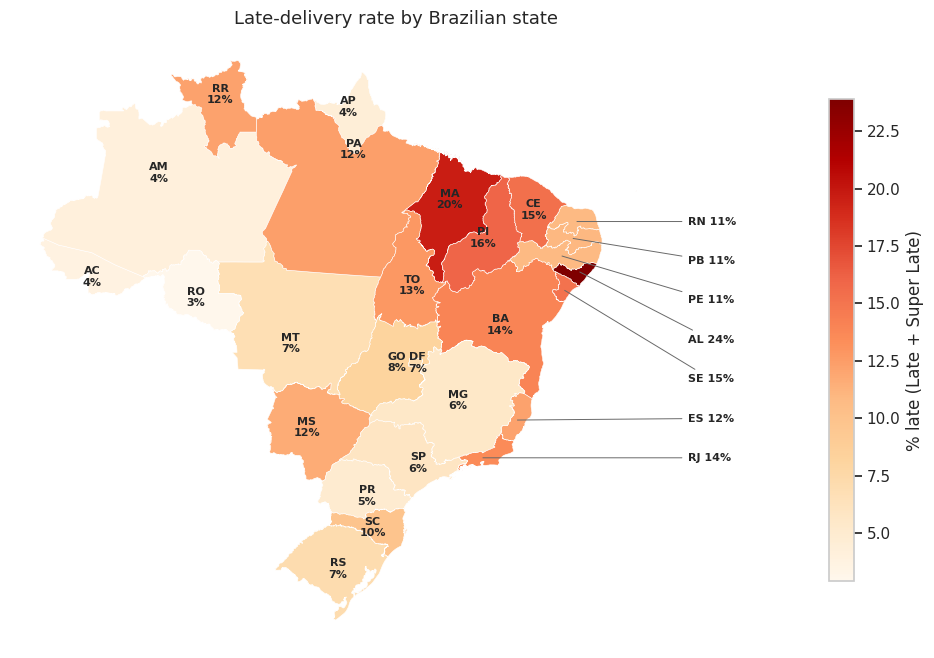

In [14]:
## chloropleth map
import json, os, urllib.request
import matplotlib.colors as mcolors
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection

GEO_URL = ("https://raw.githubusercontent.com/codeforgermany/click_that_hood/"
           "main/public/data/brazil-states.geojson")
GEO_LOCAL = "brazil_states.geojson"

geojson = None
try:
    if not os.path.exists(GEO_LOCAL):
        print("Downloading Brazil state boundaries (one-off)...")
        urllib.request.urlretrieve(GEO_URL, GEO_LOCAL)
    with open(GEO_LOCAL, encoding="utf-8") as f:
        geojson = json.load(f)
except Exception as e:                       
    print(f"Could not obtain the GeoJSON ({e}). The ranked bar chart above shows the same data.")

if geojson is not None:
    rate = dict(zip(state_perf["customer_state"], state_perf["pct_late"]))
    norm = mcolors.Normalize(state_perf["pct_late"].min(), state_perf["pct_late"].max())

    polygons, values, centroid = [], [], {}
    for feat in geojson["features"]:
        uf = feat["properties"]["sigla"]
        if uf not in rate:
            continue
        geom = feat["geometry"]
        parts = geom["coordinates"] if geom["type"] == "MultiPolygon" else [geom["coordinates"]]
        biggest, biggest_n = None, -1
        for part in parts:
            ring = np.array(part[0])                        
            polygons.append(MplPolygon(ring, closed=True))
            values.append(rate[uf])
            if len(ring) > biggest_n:                      # label on the largest piece
                biggest_n, biggest = len(ring), ring
        centroid[uf] = biggest.mean(axis=0)

    fig, ax = plt.subplots(figsize=(10, 10))
    pc = PatchCollection(polygons, cmap=plt.cm.OrRd, norm=norm,
                         edgecolor="white", linewidths=0.4)
    pc.set_array(np.array(values)); ax.add_collection(pc)
    ax.autoscale(); ax.set_aspect("equal"); ax.axis("off")
    x0, x1 = ax.get_xlim(); ax.set_xlim(x0, x1 + 8)        # room for external labels

    # Small pieces get external labels with leader lines;
    # everyone else is labelled in place.
    EXTERNAL = ["RN", "PB", "PE", "AL", "SE", "ES", "RJ"]
    for uf, (lon, lat) in centroid.items():
        if uf not in EXTERNAL:
            ax.annotate(f"{uf}\n{rate[uf]:.0f}%", (lon, lat), ha="center", va="center",
                        fontsize=8, fontweight="bold")
    ext = sorted(EXTERNAL, key=lambda u: centroid[u][1], reverse=True)
    ys = np.linspace(max(centroid[u][1] for u in ext), min(centroid[u][1] for u in ext), len(ext))
    for uf, ly in zip(ext, ys):
        lon, lat = centroid[uf]
        ax.annotate(f"{uf} {rate[uf]:.0f}%", xy=(lon, lat), xytext=(x1 + 1.5, ly),
                    fontsize=8, fontweight="bold", va="center",
                    arrowprops=dict(arrowstyle="-", color="dimgray", lw=0.7))

    fig.colorbar(pc, ax=ax, shrink=0.5, label="% late (Late + Super Late)")
    ax.set_title("Late-delivery rate by Brazilian state", fontsize=13)
    plt.tight_layout(); plt.show()

Each state has its late% with darkest been critical.

### Are "remote" states (far from the distribution centre) disproportionately affected?

If **São
Paulo (SP)** is Olist's logistics hub, so we measure each state's great-circle distance from SP
(using the geolocation coordinates) and correlate it with delivery performance.


Correlation of distance-from-hub with:
  actual delivery time  : +0.91   <- very strong
  promise gap (padding) : +0.51
  late rate             : +0.15   <- weak


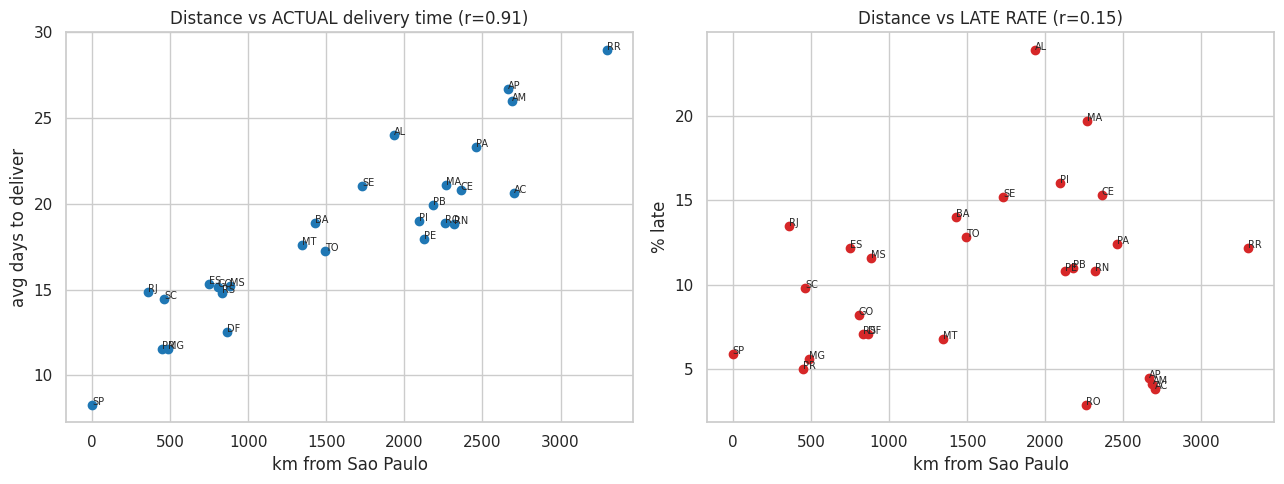

In [15]:
# Distance of each state from the Sao Paulo hub, from the provided geolocation coordinates
geo = pd.read_csv("olist_geolocation_dataset.csv")
geo = geo[geo["geolocation_lat"].between(-34, 6) & geo["geolocation_lng"].between(-74, -28)]
hub = geo.groupby("geolocation_state")[["geolocation_lat", "geolocation_lng"]].median()
sp_lat, sp_lng = hub.loc["SP"]

def haversine_km(lat, lng):
    R = 6371.0
    dlat, dlng = np.radians(lat - sp_lat), np.radians(lng - sp_lng)
    a = (np.sin(dlat / 2) ** 2
         + np.cos(np.radians(sp_lat)) * np.cos(np.radians(lat)) * np.sin(dlng / 2) ** 2)
    return 2 * R * np.arcsin(np.sqrt(a))
hub["dist_km"] = haversine_km(hub["geolocation_lat"], hub["geolocation_lng"])

# Actual delivery duration per state
delivered["actual_days"] = (delivered["order_delivered_customer_date"]
                            - delivered["order_purchase_timestamp"]).dt.days
transit = delivered.groupby("customer_state")["actual_days"].mean()

remote = (state_perf
          .merge(hub["dist_km"], left_on="customer_state", right_index=True)
          .merge(transit.rename("avg_delivery_days"), left_on="customer_state", right_index=True))

print("Correlation of distance-from-hub with:")
print(f"  actual delivery time  : {remote['dist_km'].corr(remote['avg_delivery_days']):+.2f}"
      "   <- very strong")
print(f"  promise gap (padding) : {remote['dist_km'].corr(remote['avg_days_diff']):+.2f}")
print(f"  late rate             : {remote['dist_km'].corr(remote['pct_late']):+.2f}"
      "   <- weak")

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].scatter(remote["dist_km"], remote["avg_delivery_days"], color="#1f77b4")
ax[1].scatter(remote["dist_km"], remote["pct_late"], color="#d62728")
for _, r in remote.iterrows():
    ax[0].annotate(r["customer_state"], (r["dist_km"], r["avg_delivery_days"]), fontsize=7)
    ax[1].annotate(r["customer_state"], (r["dist_km"], r["pct_late"]), fontsize=7)
ax[0].set(title=f"Distance vs ACTUAL delivery time "
          f"(r={remote['dist_km'].corr(remote['avg_delivery_days']):.2f})",
          xlabel="km from Sao Paulo", ylabel="avg days to deliver")
ax[1].set(title=f"Distance vs LATE RATE (r={remote['dist_km'].corr(remote['pct_late']):.2f})",
          xlabel="km from Sao Paulo", ylabel="% late")
plt.tight_layout(); plt.show()

**Remoteness drives delivery *time*, but estimate-padding hides it in the late-rate.**

- **Distance explains actual delivery time almost perfectly (r ≈ 0.91):** the farthest states (RR, AP,
  AM, AC) take ~26–29 days to arrive versus ~8–12 in the south-east. So physically, yes remote
  regions are hit hardest.
- **Yet distance barely predicts the late-rate (r ≈ 0.15).** The reason is Olist pads the
  estimate *more* for remote states, so the far-north is quoted
  30+ days and a 26-day delivery still counts as "on time."
- **Who is therefore disproportionately *late*? The mid-distance North-east** (AL, MA, PI, CE, SE
  ~2,000 km). Delivery is slow **and** the padding is not generous enough, so they carry the worst
  late-rates (15–24%). The deep-remote Amazon only "looks" fine because expectations were set low.

We do have remoteness problems, but it surfaces as broken promises
specifically in the **North-east**. If we want to base on  that, that is where  effort should go first. 


## Story 4 — The Sentiment Correlation

> *As a Customer Success Lead, I want to see if late deliveries actually cause bad reviews,
> so that I can prove to the CEO that logistics is the problem.*

**Does lateness
depress the rating?**


In [16]:
rated = delivered[delivered["review_score"].notna()].copy()

by_status = (rated.groupby("delivery_status")["review_score"]
             .agg(["mean", "count"]).reindex(status_order))
by_status["mean"] = by_status["mean"].round(2)
print("Average review score by delivery status:")
print(by_status)



Average review score by delivery status:
                 mean  count
delivery_status             
On Time          4.29  88163
Late             3.46   3568
Super Late       1.78   4093


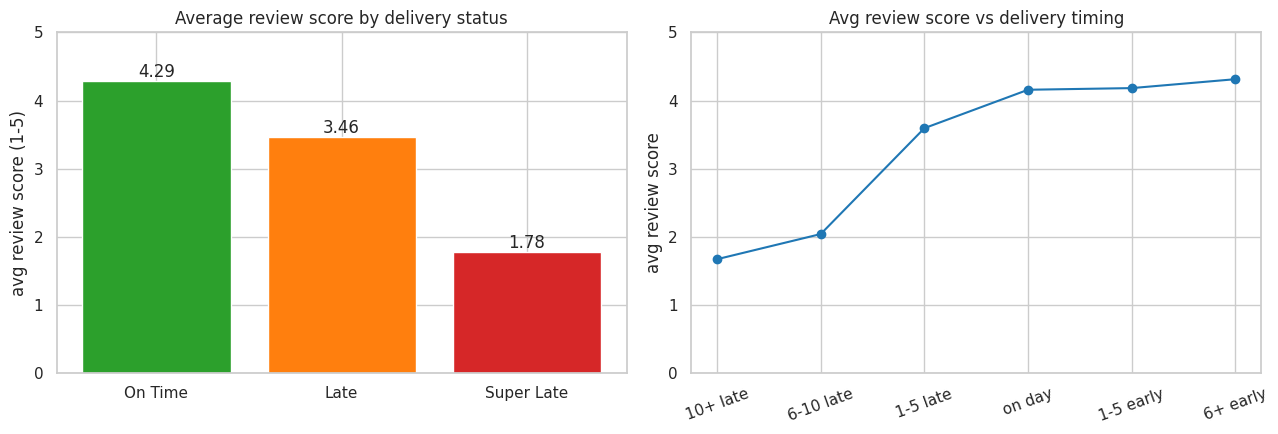

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].bar(status_order, by_status["mean"].values,
          color=[colors[s] for s in status_order])
ax[0].set_ylim(0, 5); ax[0].set_ylabel("avg review score (1-5)")
ax[0].set_title("Average review score by delivery status")
for i, v in enumerate(by_status["mean"].values):
    ax[0].text(i, v, f"{v}", ha="center", va="bottom")

# Avg score across binned delay
bins = [-100, -10, -5, -1, 0, 5, 100]
labels = ["10+ late", "6-10 late", "1-5 late", "on day", "1-5 early", "6+ early"]
rated["delay_bin"] = pd.cut(rated["Days_Difference"], bins=bins, labels=labels)
binned = rated.groupby("delay_bin", observed=True)["review_score"].mean()
ax[1].plot(binned.index.astype(str), binned.values, marker="o", color="#1f77b4")
ax[1].set_ylim(0, 5); ax[1].set_title("Avg review score vs delivery timing")
ax[1].set_ylabel("avg review score"); plt.setp(ax[1].get_xticklabels(), rotation=20)
plt.tight_layout(); plt.show()

 Satisfaction collapses with lateness. On-time orders average well above 4 stars,
*Late* orders drop sharply, and *Super Late* orders average close to ~2 stars. The monotonic
decline confirms the CEO's instinct: **broken delivery promises are a primary driver of the
negative-review spike**, so this is a logistics problem, not a product problem.


## Translation to find meaning in the item categories

> *As a Global Analyst, I want product categories in English, so I can see if "Furniture" is harder
> to ship than "Electronics".*

To attach a category to each order we follow the relational chain
**orders → order_items → products → translation**, then look at delivery performance by
(English) category.


In [18]:
# orders -> items -> products -> english category
item_cat = (items[["order_id", "product_id"]]
            .merge(products[["product_id", "product_category_name"]], on="product_id")
            .merge(translation, on="product_category_name", how="left"))
item_cat["product_category_name_english"] = (
    item_cat["product_category_name_english"].fillna(item_cat["product_category_name"]))

# one category per order to avoid double counting orders
order_cat = item_cat.drop_duplicates("order_id")[["order_id",
                                                  "product_category_name_english"]]
delivered_cat = delivered.merge(order_cat, on="order_id", how="left")

cat_perf = (delivered_cat.dropna(subset=["product_category_name_english"])
            .assign(is_late=delivered_cat["delivery_status"] != "On Time")
            .groupby("product_category_name_english")
            .agg(orders=("order_id", "size"), pct_late=("is_late", "mean"))
            .query("orders >= 500")
            .sort_values("pct_late", ascending=False))
cat_perf["pct_late"] = (cat_perf["pct_late"] * 100).round(1)
print("Late rate by product category (>=500 orders):\n")
print(cat_perf.head(10).to_string())

Late rate by product category (>=500 orders):

                                 orders  pct_late
product_category_name_english                    
electronics                        2507       9.9
baby                               2763       9.3
office_furniture                   1246       9.2
construction_tools_construction     728       9.2
health_beauty                      8608       9.0
musical_instruments                 607       8.9
bed_bath_table                     9167       8.8
auto                               3792       8.6
furniture_decor                    6213       8.6
watches_gifts                      5470       8.6


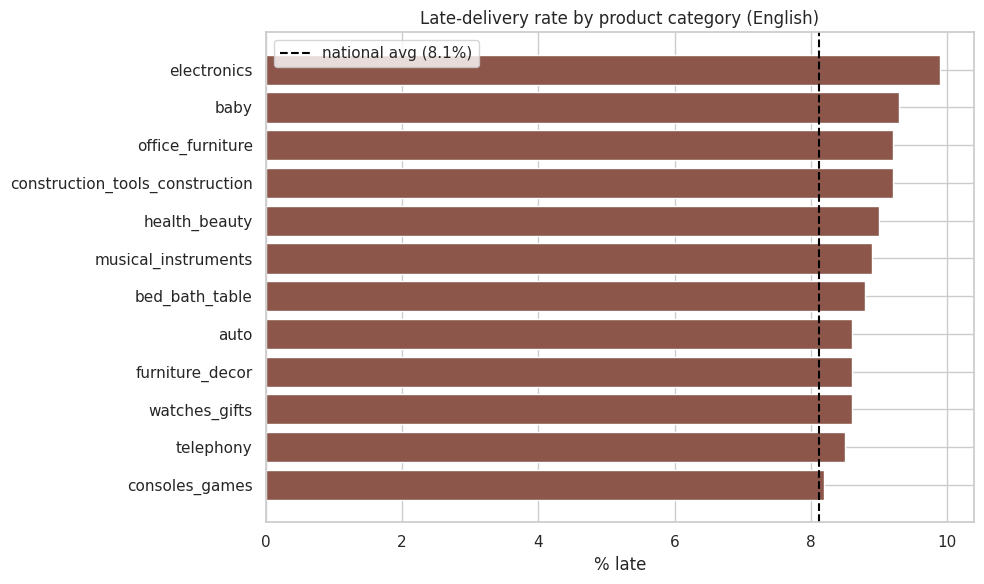

In [19]:
top = cat_perf.head(12)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top.index[::-1], top["pct_late"][::-1], color="#8c564b")
ax.axvline(national, color="black", ls="--", label=f"national avg ({national:.1f}%)")
ax.set_xlabel("% late"); ax.set_title("Late-delivery rate by product category (English)")
ax.legend(); plt.tight_layout(); plt.show()

The above plot gives how each category takes to be shipped. It can be seen that electronics are harder to ship than furniture. 

### Insightful routes (candidate's Choice)

Based on what we have already done, more can be done to give more informed decisions.


### Where does the time leak? (Delivery-pipeline bottleneck)

Knowing *which* states are late doesn't tell operations *what* to fix. Here we break every
delivery into its internal stages and measure where the days actually go.

`purchase → [approval] → seller hands to carrier → [handling] → carrier delivers → [transit]`

If time is lost in **handling**, the fix is seller/warehouse Service Level Agreement (SLA). If it is lost in **transit**, the
fix is the carrier network. 


Average days per stage (and share of total delivery time):
  Payment approval:  0.43 days  ( 3.4%)
  Seller handling :  2.80 days  (22.3%)
  Carrier transit :  9.33 days  (74.3%)

Avg stage duration — On Time vs Late:
         s1_approval  s2_handling  s3_transit
On Time         0.42         2.58        7.89
Late            0.51         5.32       25.68


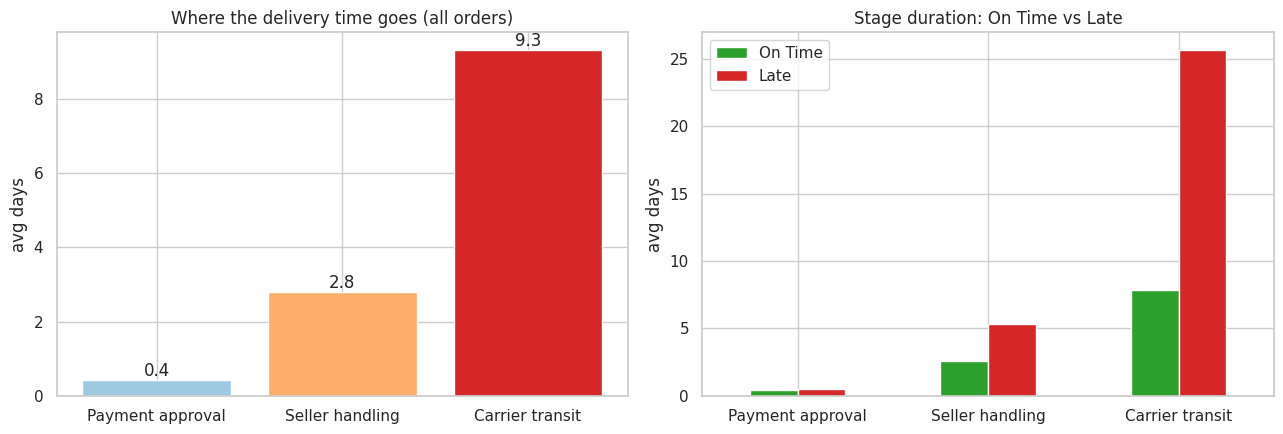

In [20]:
# Break each delivery into internal stages 
stage_src = delivered.copy()
stage_src["order_approved_at"] = pd.to_datetime(stage_src["order_approved_at"], errors="coerce")
stage_src["order_delivered_carrier_date"] = pd.to_datetime(
    stage_src["order_delivered_carrier_date"], errors="coerce")
stage_src["s1_approval"] = (stage_src["order_approved_at"]
                            - stage_src["order_purchase_timestamp"]).dt.total_seconds() / 86400
stage_src["s2_handling"] = (stage_src["order_delivered_carrier_date"]
                            - stage_src["order_approved_at"]).dt.total_seconds() / 86400
stage_src["s3_transit"] = (stage_src["order_delivered_customer_date"]
                           - stage_src["order_delivered_carrier_date"]).dt.total_seconds() / 86400
stages = ["s1_approval", "s2_handling", "s3_transit"]
labels = ["Payment approval", "Seller handling", "Carrier transit"]

avg_stage = stage_src[stages].mean()
share = avg_stage / avg_stage.sum() * 100
print("Average days per stage (and share of total delivery time):")
for s, l in zip(stages, labels):
    print(f"  {l:16s}: {avg_stage[s]:5.2f} days  ({share[s]:4.1f}%)")

by_late = stage_src.groupby(stage_src["delivery_status"].ne("On Time"))[stages].mean()
by_late.index = ["On Time", "Late"]
print("\nAvg stage duration — On Time vs Late:")
print(by_late.round(2))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].bar(labels, avg_stage.values, color=["#9ecae1", "#fdae6b", "#d62728"])
ax[0].set_ylabel("avg days"); ax[0].set_title("Where the delivery time goes (all orders)")
for i, v in enumerate(avg_stage.values):
    ax[0].text(i, v, f"{v:.1f}", ha="center", va="bottom")
by_late.T.plot(kind="bar", ax=ax[1], color=["#2ca02c", "#d62728"])
ax[1].set_xticklabels(labels, rotation=0); ax[1].set_ylabel("avg days")
ax[1].set_title("Stage duration: On Time vs Late"); ax[1].legend(title="")
plt.tight_layout(); plt.show()

Carrier **transit dominates** ~74% of all delivery
time, and it is the stage that *explodes* on late orders. Transit jumps from ~8 days (on-time) to
~26 days (late), while seller handling only rises from ~2.6 to ~5.3 days and payment approval is
negligible. There should be attention and investments in carrier capacity and routing (especially for the remote North-east).


### Next - Revenue at risk

Lateness is always a financial problem. Joining the order payment values lets us size the
exposure in **R$**, the number that drives executive action  and reveals that *where the money is*
is not the same as *where the rate is worst*. Here we investigate how much revenue is associated with late deliveries so we become aware  of potential revenue we might lose if we don't take action and customers get fed up.



Total delivered revenue : R$ 15,421,083
Revenue on LATE orders  : R$ 1,351,647  (8.8% of revenue at risk)
Avg order value — late R$ 173 vs on-time R$ 159


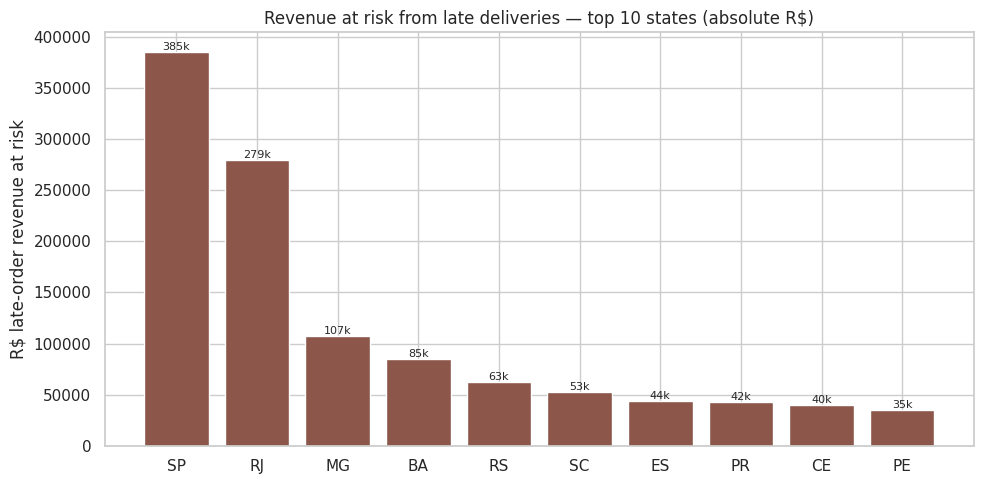

In [21]:
payments = pd.read_csv("olist_order_payments_dataset.csv")
order_value = payments.groupby("order_id")["payment_value"].sum()
rev = delivered.merge(order_value.rename("order_value"),
                      left_on="order_id", right_index=True, how="left")
rev["is_late"] = rev["delivery_status"].ne("On Time")

total_rev = rev["order_value"].sum()
late_rev = rev.loc[rev["is_late"], "order_value"].sum()
print(f"Total delivered revenue : R$ {total_rev:,.0f}")
print(f"Revenue on LATE orders  : R$ {late_rev:,.0f}  "
      f"({late_rev / total_rev * 100:.1f}% of revenue at risk)")
print(f"Avg order value — late R$ {rev.loc[rev['is_late'], 'order_value'].mean():.0f} "
      f"vs on-time R$ {rev.loc[~rev['is_late'], 'order_value'].mean():.0f}")

state_rev = (rev[rev["is_late"]].groupby("customer_state")["order_value"].sum()
             .sort_values(ascending=False).head(10))
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(state_rev.index, state_rev.values, color="#8c564b")
ax.set_ylabel("R$ late-order revenue at risk")
ax.set_title("Revenue at risk from late deliveries — top 10 states (absolute R$)")
for i, v in enumerate(state_rev.values):
    ax.text(i, v, f"{v/1000:.0f}k", ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.show()

About **R$1.35M (~8.8%) of delivered
revenue** is tied to late orders, and late orders are *slightly higher value* than on-time ones
(R$173 vs R$159). Critically, the **absolute revenue
at is concentrated in the high-volume south-east (SP, RJ, MG)** even though their late rate is
low, while the North-east has the worst rate but less money at stake. **A strategic way** is to
protect *revenue* by hardening more on SP/RJ reliability, and protect *reputation & retention* by fixing the
North-east rate.


## Executive Findings & Recommendations

**What we found**
1. **It is regional, not nationwide.** The national late rate is only ~8%, but it is concentrated in
   the **North-eastern states** — Alagoas (~24%), Maranhão (~20%), Piauí (~16%), Ceará and Sergipe
   (~15%) which run 2–3× the national average. The reliable south-east drags the national figure
   down and masks the problem.
2. **Lateness directly destroys satisfaction.** Average review scores fall from on-time (**4.29★**)
   to Late (**3.46★**) to Super-Late (**1.78★**).
3. **The main factor of the lateness**. It was found that along the process in order for a customer to receive the package, transit is the major delay and the company should take measures to addressing this and serve customers well.
4. **Revenue at risk**.  R$1.35M (~8.8%) of delivered revenue are from late deliveries that the CEO should be cautious of that. In as much of we are saving revenue, we are also tightening reliability and reputation. 

<!-- **Recommendations**
- **Add last-mile capacity / carrier partners in the North-east** (AL, MA, PI, CE, SE), where both
  late rate and customer anger are highest — padding alone cannot fix it there.
- **Tighten the over-padded far-north estimates** (RO, AC, AM, AP) to stay speed/price competitive.
- **Re-baseline estimates per state** so the promise matches regional reality (cheapest, fastest win).
- **Monitor the Promise Gap and late-rate monthly** via the companion Streamlit dashboard so
  regressions surface before they hit reviews. -->
